In [1]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("/content/diabetes.csv")

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.corr()['Outcome']

,Outcome
Pregnancies,0.221898
Glucose,0.466581
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
BMI,0.292695
DiabetesPedigreeFunction,0.173844
Age,0.238356
Outcome,1.000000


In [6]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [8]:
X = scaler.fit_transform(X)

In [9]:
X.shape

(768, 8)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [92]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Dropout


In [17]:
model = Sequential()

model.add(Dense(32,activation='relu',input_dim=8))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'] )



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.fit(X_train,y_train,batch_size=32,epochs=100,validation_data=(X_test,y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7638 - loss: 0.4979 - val_accuracy: 0.7987 - val_loss: 0.4571
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7671 - loss: 0.4909 - val_accuracy: 0.8052 - val_loss: 0.4500
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7671 - loss: 0.4855 - val_accuracy: 0.8052 - val_loss: 0.4445
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7687 - loss: 0.4806 - val_accuracy: 0.8052 - val_loss: 0.4405
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7736 - loss: 0.4771 - val_accuracy: 0.8117 - val_loss: 0.4358
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7752 - loss: 0.4741 - val_accuracy: 0.7987 - val_loss: 0.4331
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7736 - loss: 0.4708 - val_accuracy: 0.8117 - val_loss: 0.4308
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7736 - loss: 0.4688 - val_accuracy: 0.8052 - 

In [21]:
#how to slect approiate the optimiaazer
# no of nodes in layers
#how tto select no of layers

In [24]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.1 MB/s eta 0:00:00


In [25]:
import kerastuner as kt


/tmp/ipykernel_2086/1654478174.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [28]:
def build_model(hp):
  model = Sequential()
  model.add(Dense(32,activation='relu',input_dim=8))
  model.add(Dense(1,activation='sigmoid'))

  model.compile(optimizer=hp.Choice('optimizer',values=['adam','sgd','rmsprop','adadelta']),loss='binary_crossentropy',metrics=['accuracy'] )
  return model

In [29]:
tuner = kt.RandomSearch(build_model,
                        objective='val_accuracy',
                        max_trials=5)

In [31]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 4 Complete [00h 00m 04s]
val_accuracy: 0.7272727489471436

Best val_accuracy So Far: 0.7922077775001526
Total elapsed time: 00h 00m 15s


In [32]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'rmsprop'}

In [34]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    initial_epoch=6,
    validation_data=(X_test, y_test)
)

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.7345 - loss: 0.5163 - val_accuracy: 0.7922 - val_loss: 0.4739
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7443 - loss: 0.5027 - val_accuracy: 0.7922 - val_loss: 0.4633
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7459 - loss: 0.4944 - val_accuracy: 0.7922 - val_loss: 0.4551
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7459 - loss: 0.4881 - val_accuracy: 0.7987 - val_loss: 0.4504
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7492 - loss: 0.4828 - val_accuracy: 0.7987 - val_loss: 0.4460
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7622 - loss: 0.4785 - val_accuracy: 0.8052 - val_loss: 0.4423
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7671 - loss: 0.4751 - val_accuracy: 0.8052 - val_loss: 0.4385
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7687 - loss: 0.4723 - val_accuracy: 0.80

In [48]:
def build_model(hp):
    model = Sequential()

    units = hp.Int(
        'units',
        min_value=8,
        max_value=128,
        step=8
    )

    model.add(Dense(units=units, activation='relu', input_dim=8))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='rmsprop',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [49]:
import keras_tuner as kt

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='mydir',
    project_name='myproject'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
tuner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 5 Complete [00h 00m 04s]
val_accuracy: 0.8181818127632141

Best val_accuracy So Far: 0.8181818127632141
Total elapsed time: 00h 00m 18s


In [52]:
tuner.get_best_hyperparameters()[0].values

{'units': 104}

In [56]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [60]:
model.fit(
    X_train,
    y_train,
    epochs=100,
    initial_epoch=6,
    validation_data=(X_test, y_test)
)

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7573 - loss: 0.5123 - val_accuracy: 0.8117 - val_loss: 0.4581
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7704 - loss: 0.4911 - val_accuracy: 0.8052 - val_loss: 0.4441
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7622 - loss: 0.4805 - val_accuracy: 0.8052 - val_loss: 0.4345
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7720 - loss: 0.4729 - val_accuracy: 0.8052 - val_loss: 0.4293
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7704 - loss: 0.4671 - val_accuracy: 0.8117 - val_loss: 0.4279
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7671 - loss: 0.4632 - val_accuracy: 0.8117 - val_loss: 0.4281
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7704 - loss: 0.4604 - val_accuracy: 0.8117 - val_loss: 0.4239
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7720 - loss: 0.4578 - val_accuracy: 0.80

In [61]:
def build_model(hp):
  model = Sequential()

  model.add(Dense(104,activation='relu',input_dim=8))

  for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
    model.add(Dense(104,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy'])
  return model


In [63]:
tunner = kt.RandomSearch(build_model,objective='val_accuracy',max_trials=3,directory='mydir',project_name='num_layers')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
tunner.search(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Trial 3 Complete [00h 00m 04s]
val_accuracy: 0.6948052048683167

Best val_accuracy So Far: 0.6948052048683167
Total elapsed time: 00h 00m 23s


In [66]:
tuner.get_best_hyperparameters(num_trials=1)[0]

In [68]:
models = tunner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [72]:
model.fit(
    X_train,
    y_train,
    epochs=100,
    initial_epoch=6,
    validation_data=(X_test, y_test)
)

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8257 - loss: 0.3959 - val_accuracy: 0.8247 - val_loss: 0.4622
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8306 - loss: 0.3960 - val_accuracy: 0.8247 - val_loss: 0.4594
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8322 - loss: 0.3960 - val_accuracy: 0.8247 - val_loss: 0.4584
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8257 - loss: 0.3950 - val_accuracy: 0.8247 - val_loss: 0.4585
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8290 - loss: 0.3943 - val_accuracy: 0.8247 - val_loss: 0.4660
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8225 - loss: 0.3959 - val_accuracy: 0.8247 - val_loss: 0.4660
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8306 - loss: 0.3936 - val_accuracy: 0.8247 - val_loss: 0.4654
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8225 - loss: 0.3925 - val_accuracy: 0.82

In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build(hp):
    model = Sequential()

    num_layers = hp.Int('num_layers', min_value=1, max_value=10)

    for i in range(num_layers):
        units = hp.Int(
            'units_' + str(i),
            min_value=8,
            max_value=128,
            step=8
        )

        activation = hp.Choice(
            'activation_' + str(i),
            values=['relu', 'tanh', 'sigmoid']
        )

        if i == 0:
            model.add(Dense(units=units,
                            activation=activation,
                            input_dim=8))
            model.add(Dropout(hp.Choice('dropout'+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
        else:
            model.add(Dense(units=units,
                            activation=activation))
            model.add(Dropout(hp.Choice('dropout'+str(i),values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))


    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=hp.Choice(
            'optimizer',
            values=['rmsprop', 'adam', 'sgd', 'nadam', 'adadelta']
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model






In [94]:
tuner = kt.RandomSearch(
    build,
    objective='val_accuracy',
    max_trials=5,
    directory='mydir',
    project_name='ann_tuninggg'
)

tuner.search(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Trial 5 Complete [00h 00m 14s]
val_accuracy: 0.6948052048683167

Best val_accuracy So Far: 0.7727272510528564
Total elapsed time: 00h 01m 00s


In [95]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 8,
 'units_0': 104,
 'activation_0': 'tanh',
 'dropout0': 0.2,
 'optimizer': 'adam',
 'units_1': 8,
 'activation_1': 'relu',
 'dropout1': 0.1,
 'units_2': 8,
 'activation_2': 'relu',
 'dropout2': 0.1,
 'units_3': 8,
 'activation_3': 'relu',
 'dropout3': 0.1,
 'units_4': 8,
 'activation_4': 'relu',
 'dropout4': 0.1,
 'units_5': 8,
 'activation_5': 'relu',
 'dropout5': 0.1,
 'units_6': 8,
 'activation_6': 'relu',
 'dropout6': 0.1,
 'units_7': 8,
 'activation_7': 'relu',
 'dropout7': 0.1}

In [96]:
model = tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [97]:
model.fit(
    X_train,
    y_train,
    epochs=200,
    initial_epoch=6,
    validation_data=(X_test, y_test)
)

Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 285ms/step - accuracy: 0.7215 - loss: 0.5562 - val_accuracy: 0.7662 - val_loss: 0.4730
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7248 - loss: 0.5423 - val_accuracy: 0.7597 - val_loss: 0.4624
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7362 - loss: 0.5149 - val_accuracy: 0.7597 - val_loss: 0.4583
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7264 - loss: 0.5269 - val_accuracy: 0.7532 - val_loss: 0.4535
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7378 - loss: 0.5313 - val_accuracy: 0.7727 - val_loss: 0.4543
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7394 - loss: 0.5091 - val_accuracy: 0.7792 - val_loss: 0.4513
Epoch 13/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7264 - loss: 0.5370 - val_accuracy: 0.7727 - val_loss: 0.4613
Epoch 14/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7280 - loss: 0.5364 - val_accuracy: 0.

In [98]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7818 - loss: 0.4293 - val_accuracy: 0.7987 - val_loss: 0.4457
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8127 - loss: 0.4447 - val_accuracy: 0.8117 - val_loss: 0.4469
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8046 - loss: 0.4286 - val_accuracy: 0.8052 - val_loss: 0.4468
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8111 - loss: 0.4379 - val_accuracy: 0.8052 - val_loss: 0.4523
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7980 - loss: 0.4418 - val_accuracy: 0.7857 - val_loss: 0.4582
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7850 - loss: 0.4536 - val_accuracy: 0.7857 - val_loss: 0.4617
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7980 - loss: 0.4402 - val_accuracy: 0.7857 - val_loss: 0.4579
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8143 - loss: 0.4389 - val_accuracy: 0.7727 

In [100]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7987 - loss: 0.4457
Test Accuracy: 0.798701286315918


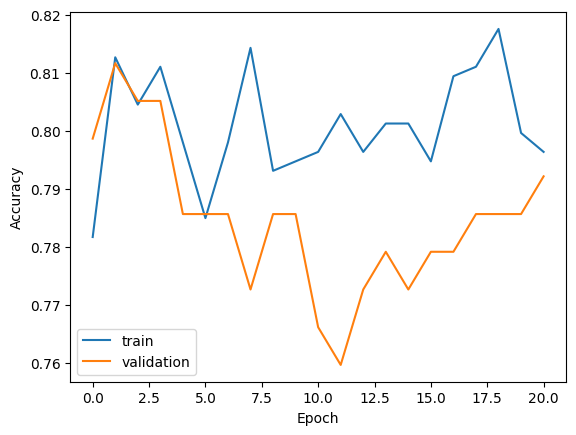

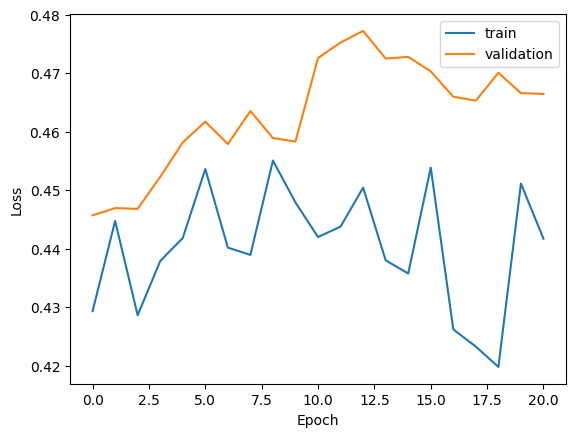

In [101]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [102]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7850 - loss: 0.4516 - val_accuracy: 0.7922 - val_loss: 0.4599
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8029 - loss: 0.4426 - val_accuracy: 0.7857 - val_loss: 0.4475
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8127 - loss: 0.4484 - val_accuracy: 0.7922 - val_loss: 0.4512
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7964 - loss: 0.4266 - val_accuracy: 0.7987 - val_loss: 0.4513
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7801 - loss: 0.4497 - val_accuracy: 0.7922 - val_loss: 0.4496
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7883 - loss: 0.4442 - val_accuracy: 0.7792 - val_loss: 0.4532
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7980 - loss: 0.4300 - val_accuracy: 0.7792 - val_loss: 0.4660
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8013 - loss: 0.4283 - val_accuracy: 0.

In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_dim=8),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


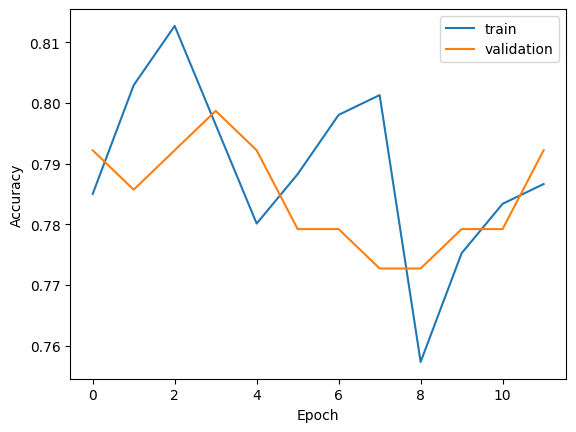

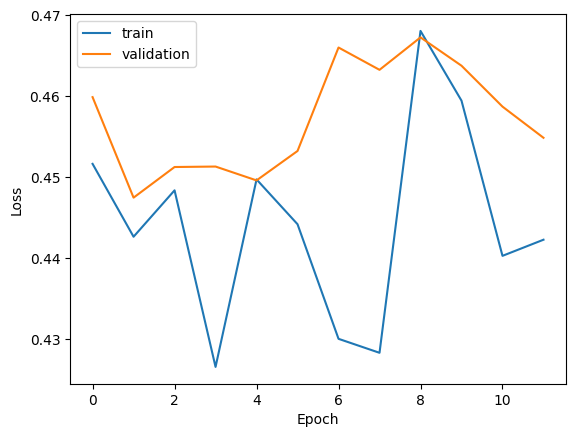

In [104]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [105]:
model.save('best_model.keras')

In [106]:
model.save('best_model.h5')